# 🌸 Iris Classification Model

Selamat datang di modul Iris Classification! Notebook ini akan memandu Anda melalui proses pembuatan model Machine Learning untuk mengklasifikasikan spesies bunga Iris.

Dataset Iris adalah dataset klasik dalam dunia Machine Learning yang berisi pengukuran fisik dari 3 spesies bunga Iris:
- **Iris-setosa**
- **Iris-versicolor**
- **Iris-virginica**

Setiap sampel memiliki 4 fitur: panjang & lebar Sepal (kelopak), serta panjang & lebar Petal (mahkota bunga).

**Perbedaan dengan notebook Crop Recommendation:**
- Menggunakan **MinMaxScaler**
- Menggunakan **Logistic Regression** (menggantikan Naive Bayes)
- Rasio split **70:30**
- Visualisasi EDA yang berbeda (Pairplot, Violin Plot, Scatter Plot)

---

## 1. Persiapan Library

Langkah pertama adalah mengimpor semua library Python yang dibutuhkan. Perhatikan bahwa di notebook ini kita menggunakan `MinMaxScaler` (bukan `StandardScaler`) dan `LogisticRegression` (menggantikan `GaussianNB`).

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

## 2. Data Loading & Eksplorasi Awal

### 2.1. Load Dataset

Membaca dataset Iris ke dalam DataFrame pandas. Dataset ini berisi 150 sampel bunga Iris dengan 4 fitur pengukuran.

In [75]:
data = pd.read_csv("../dataset/Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 2.2. Pembersihan dan Inspeksi Kolom

Langkah pembersihan awal:
1. Hapus kolom `Id` yang tidak relevan sebagai fitur prediktif
2. Rename kolom `Species` menjadi `label` untuk konsistensi
3. Cek info dataset (tipe data, jumlah entri)

In [76]:
# Hapus kolom Id dan rename kolom Species
data = data.drop(columns='Id')
data.rename(columns={'Species': 'label'}, inplace=True)

print(f"Dataset shape: {data.shape}")
print()
data.info()

Dataset shape: (150, 5)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   label          150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


### 2.3. Statistik Deskriptif

Melihat ringkasan statistik (rata-rata, nilai minimum/maksimum, kuartil) dari fitur-fitur numerik untuk memahami distribusi dasar dari data.

In [77]:
data.describe(include='all')

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,label
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


### 2.4. Deteksi Missing Values

Memeriksa apakah terdapat nilai yang hilang (*missing values/NaN*) pada dataset. Data yang hilang perlu ditangani (misalnya diisi atau dihapus) agar tidak mengganggu proses training model.

In [78]:
data_null = data.isnull().sum()
data_null[data_null > 0]

Series([], dtype: int64)

### 2.5. Deteksi Data Duplikat

Memeriksa dan menghapus baris data yang duplikat untuk memastikan model belajar dari informasi yang unik dan bervariasi.

In [79]:
duplicate = data. duplicated()
print(data[duplicate])

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm           label
34             4.9           3.1            1.5           0.1     Iris-setosa
37             4.9           3.1            1.5           0.1     Iris-setosa
142            5.8           2.7            5.1           1.9  Iris-virginica


### 2.6. Distribusi Label

Melihat komposisi setiap kelas pada kolom target (`label`). Dataset Iris terkenal karena distribusi kelasnya yang **seimbang** (masing-masing 50 sampel).

In [80]:
jumlah_unik = data['label'].nunique()
print(f"Jumlah label unik: {jumlah_unik}")
print()
print(data['label'].value_counts())

Jumlah label unik: 3

label
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

### 3.1. Pairplot (Scatter Matrix)

**Pairplot** menampilkan hubungan antar setiap pasangan fitur sekaligus, dengan warna berbeda untuk setiap kelas. Ini adalah cara paling efektif untuk melihat seberapa baik fitur memisahkan kelas-kelas pada dataset kecil seperti Iris.

**Konsep:**
- Diagonal → distribusi (histogram/KDE) tiap fitur per kelas
- Off-diagonal → scatter plot antar 2 fitur
- Jika titik-titik terpisah jelas antar warna → fitur tersebut baik untuk klasifikasi

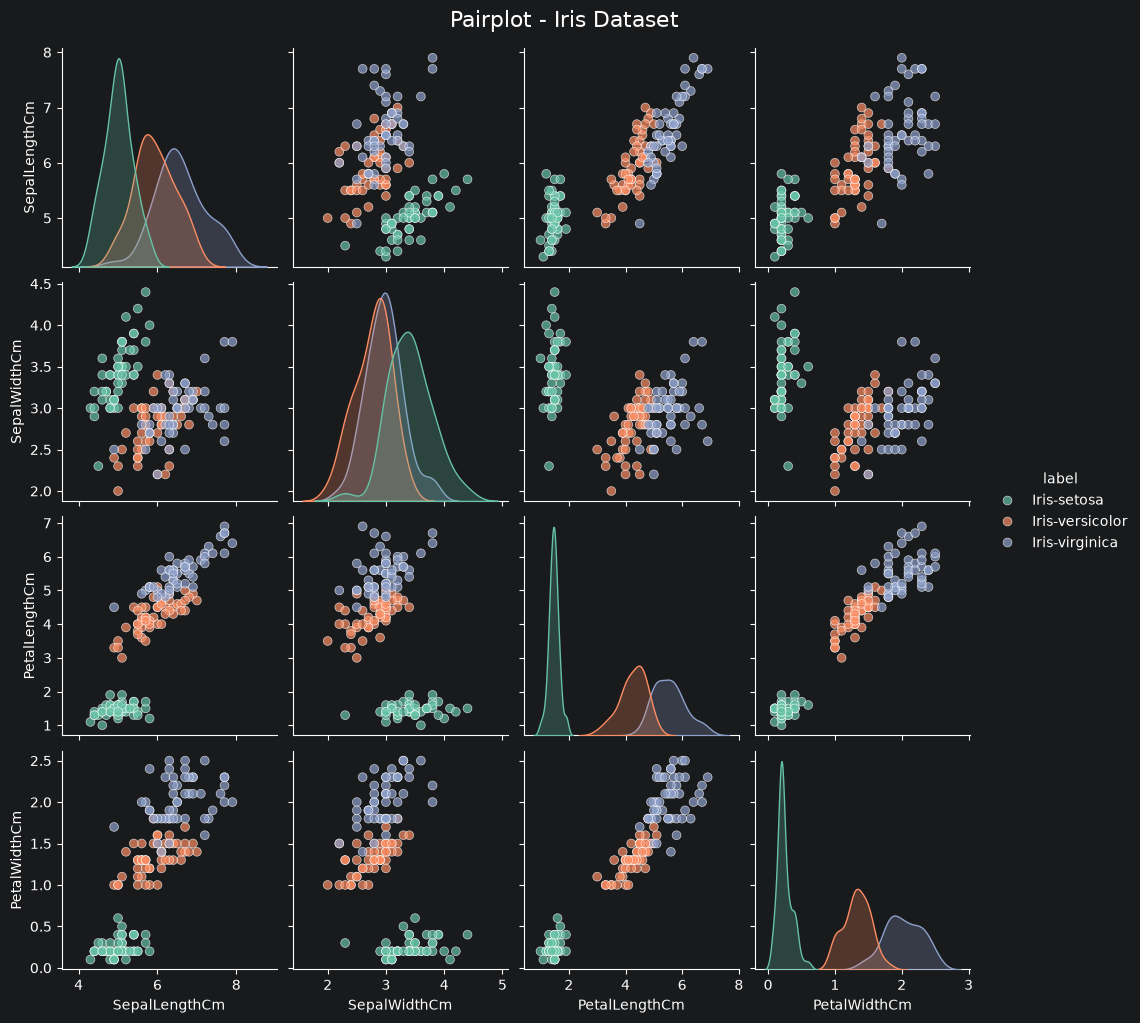

In [81]:
# Pairplot - visualisasi hubungan antar fitur per kelas
sns.pairplot(data, hue='label', palette='Set2', diag_kind='kde',
             plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'white'})
plt.suptitle('Pairplot - Iris Dataset', y=1.02, fontsize=16)
plt.show()

### 3.2. Violin Plot per Fitur

**Violin Plot** menggabungkan informasi dari box plot dan KDE plot. Bentuk "biola" menunjukkan distribusi data, sementara garis di tengah menunjukkan median dan quartile.

**Konsep:**
- Lebar violin → kepadatan data di rentang nilai tersebut
- Lebih informatif daripada box plot biasa karena menunjukkan bentuk distribusi
- Berguna untuk membandingkan distribusi fitur antar kelas

/tmp/ipykernel_51944/984691397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=col, data=data, palette='Set2',
/tmp/ipykernel_51944/984691397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=col, data=data, palette='Set2',
/tmp/ipykernel_51944/984691397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=col, data=data, palette='Set2',
/tmp/ipykernel_51944/984691397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

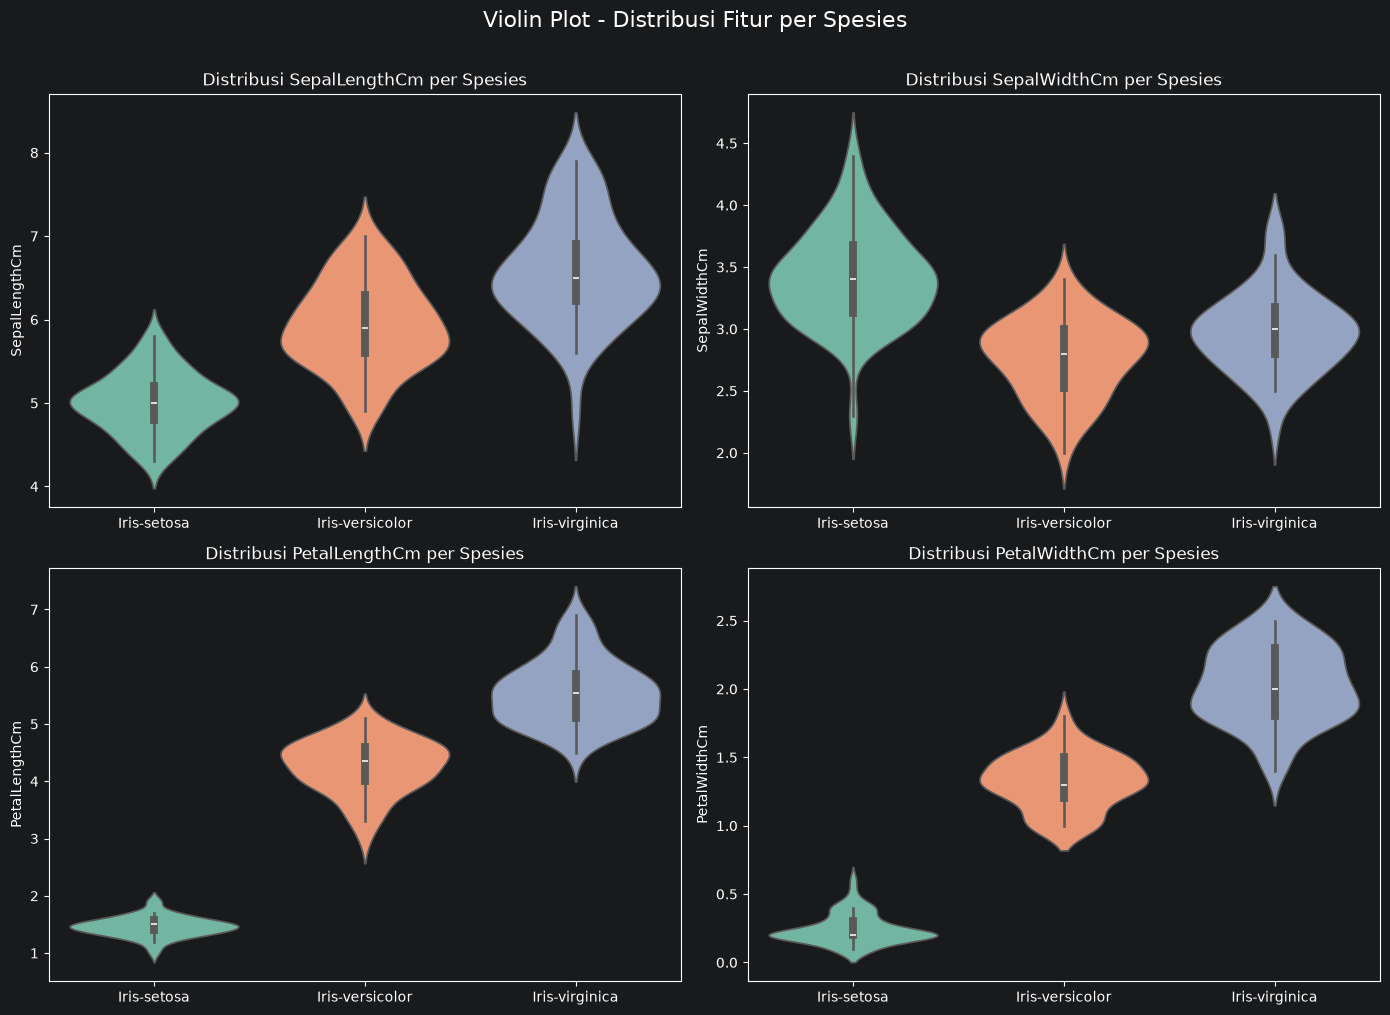

In [82]:
# Ambil fitur numerik sebagai DataFrame
num_features = data.select_dtypes(include=[np.number])
num_cols = num_features.columns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(x='label', y=col, data=data, palette='Set2',
                   inner='box', ax=axes[i])
    axes[i].set_title(f'Distribusi {col} per Spesies', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Violin Plot - Distribusi Fitur per Spesies', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.3. Swarm Plot (Deteksi Outlier & Sebaran Individual)

**Swarm Plot** menampilkan setiap titik data secara individual tanpa overlap, sehingga kita bisa melihat distribusi aktual dan mendeteksi outlier secara visual.

**Konsep:**
- Setiap titik = 1 sampel data
- Titik yang jauh dari kelompok utama = potensi outlier
- Lebih detail dibanding box plot karena tidak ada informasi yang "tersembunyi"

/tmp/ipykernel_51944/2079935213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='label', y=col, data=data, palette='Set2',
/tmp/ipykernel_51944/2079935213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='label', y=col, data=data, palette='Set2',
/tmp/ipykernel_51944/2079935213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='label', y=col, data=data, palette='Set2',
/tmp/ipykernel_51944/2079935213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the 

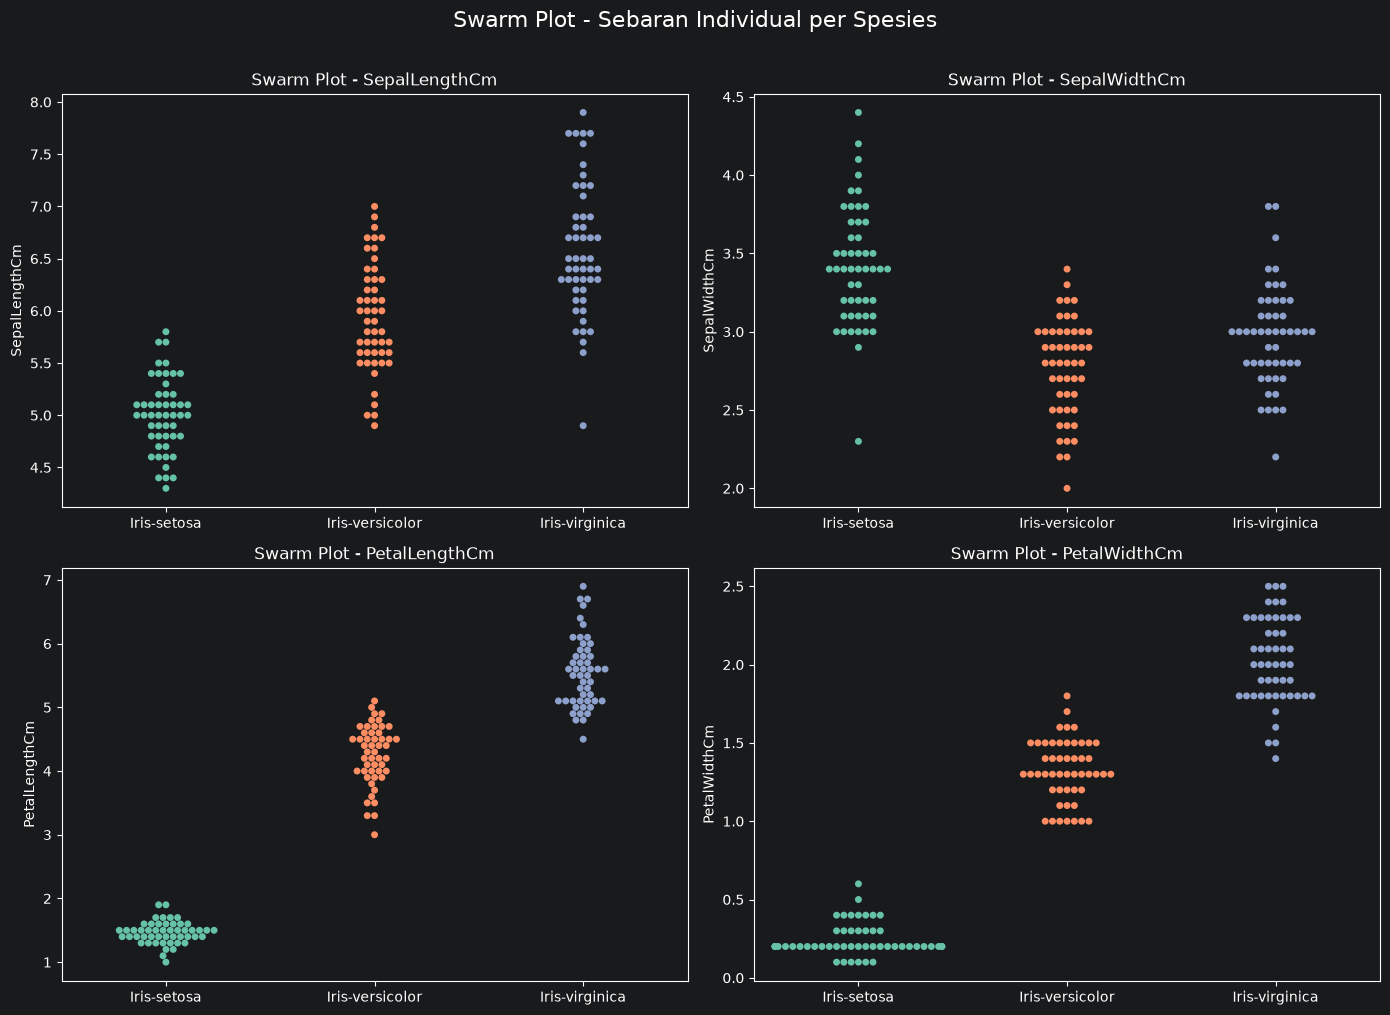

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.swarmplot(x='label', y=col, data=data, palette='Set2',
                  size=5, ax=axes[i])
    axes[i].set_title(f'Swarm Plot - {col}', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Swarm Plot - Sebaran Individual per Spesies', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.4. Matriks Korelasi

Melihat hubungan linear antar fitur menggunakan *Heatmap Korelasi*. Korelasi tinggi antar fitur (multikolinearitas) terkadang bisa menjadi isu pada beberapa algoritma.

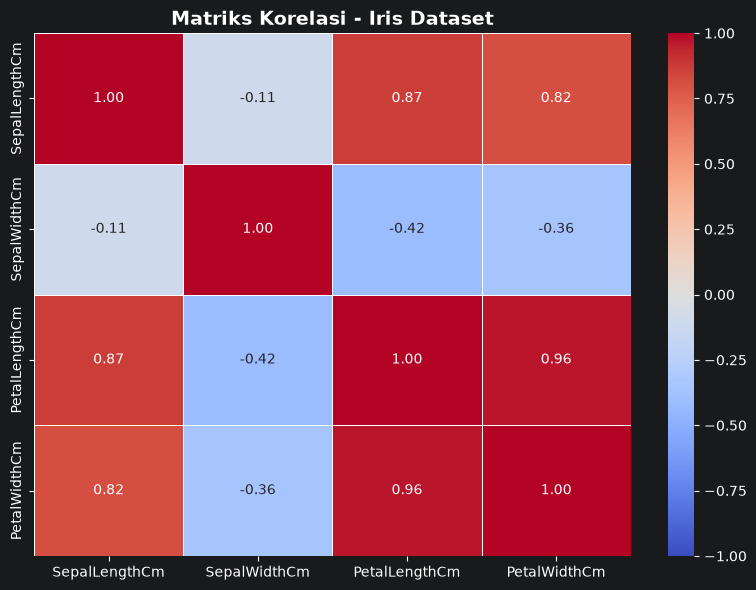

In [84]:
plt.figure(figsize=[8, 6])
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi - Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5. Scatter Plot - Fitur Terbaik

Menampilkan scatter plot dari 2 fitur yang paling baik memisahkan kelas. Dari pairplot sebelumnya, kita bisa melihat bahwa **PetalLengthCm** dan **PetalWidthCm** paling efektif memisahkan ketiga spesies.

**Konsep:**
- Scatter plot 2D membantu memvisualisasikan decision boundary
- Jika cluster terpisah jelas → model akan mudah mengklasifikasikan

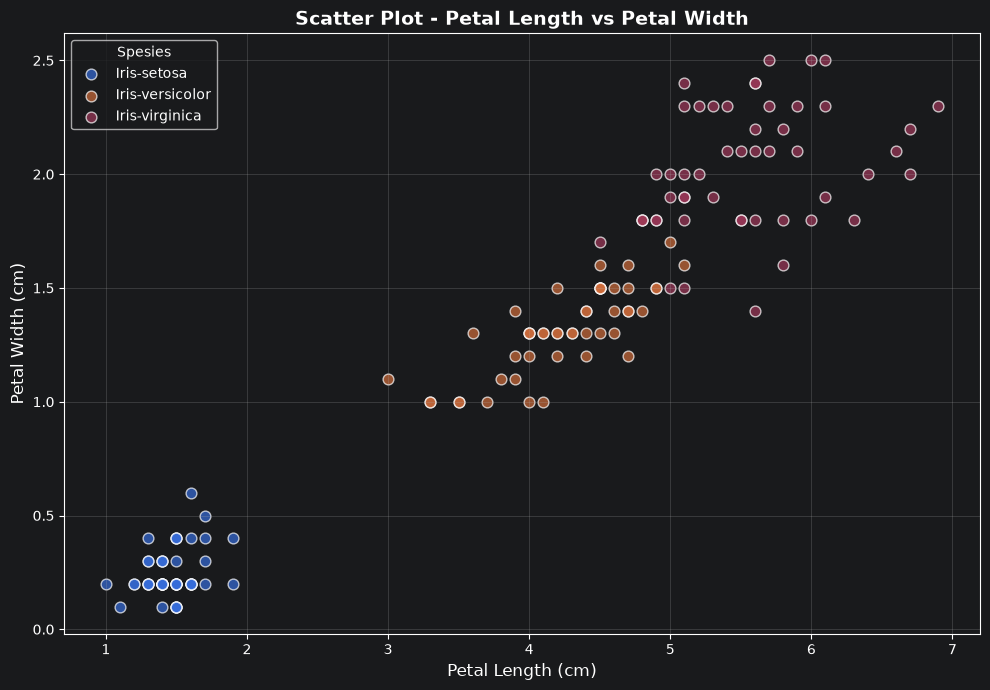

In [85]:
plt.figure(figsize=(10, 7))

for species in data['label'].unique():
    subset = data[data['label'] == species]
    plt.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'],
                label=species, alpha=0.7, s=60, edgecolors='white')

plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.title('Scatter Plot - Petal Length vs Petal Width', fontsize=14, fontweight='bold')
plt.legend(title='Spesies', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6. Scatter Plot - Sepal Features

Membandingkan scatter plot untuk fitur Sepal. Perhatikan bahwa fitur Sepal kurang efektif dalam memisahkan spesies dibandingkan fitur Petal.

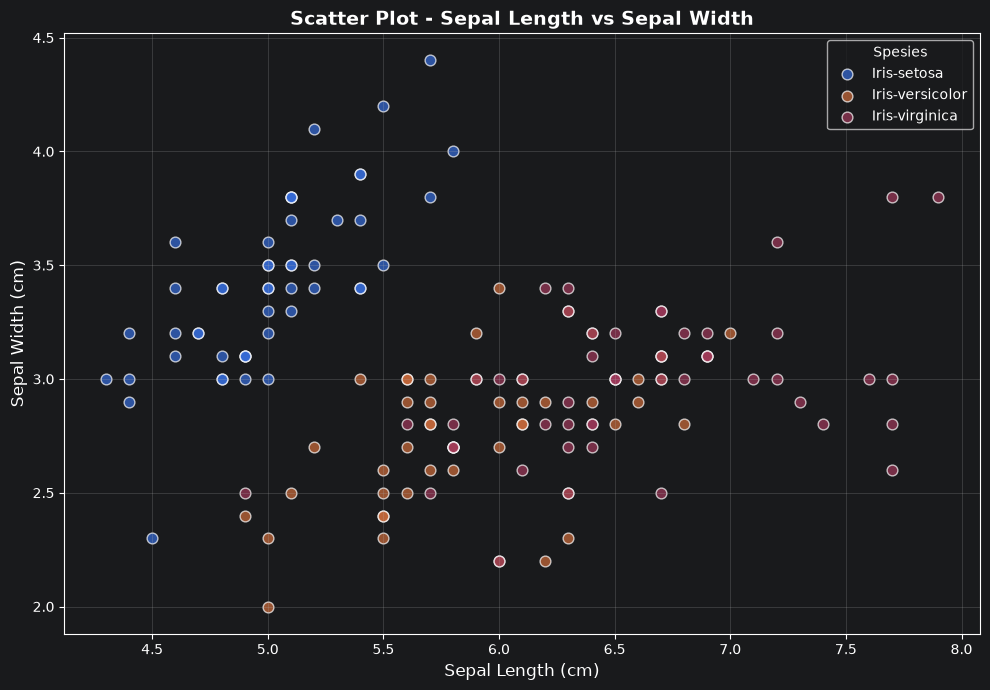

In [86]:
plt.figure(figsize=(10, 7))

for species in data['label'].unique():
    subset = data[data['label'] == species]
    plt.scatter(subset['SepalLengthCm'], subset['SepalWidthCm'],
                label=species, alpha=0.7, s=60, edgecolors='white')

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.title('Scatter Plot - Sepal Length vs Sepal Width', fontsize=14, fontweight='bold')
plt.legend(title='Spesies', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7. Distribusi Fitur per Kelas (FacetGrid KDE)

Menggunakan **KDE plot** (Kernel Density Estimation) per kelas untuk melihat bentuk distribusi setiap fitur secara smooth.

**Konsep:**
- KDE menghasilkan kurva distribusi yang lebih halus dibanding histogram
- Berguna untuk membandingkan apakah distribusi fitur tumpang tindih antar kelas

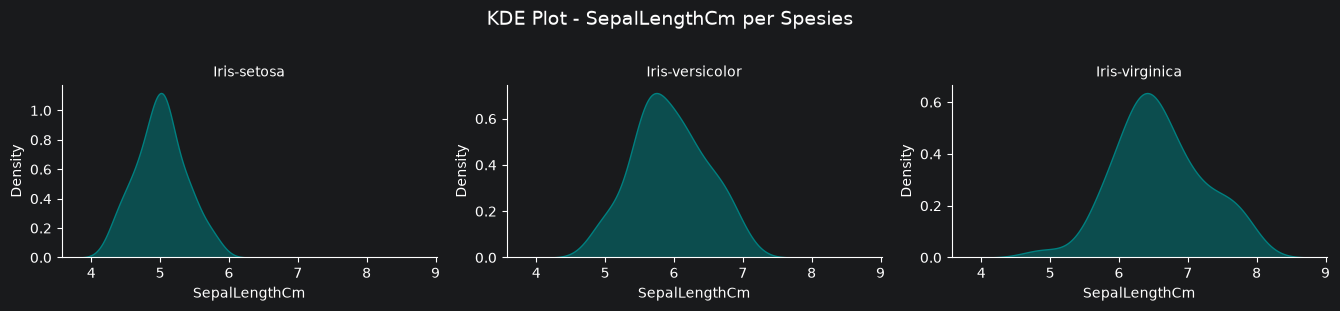

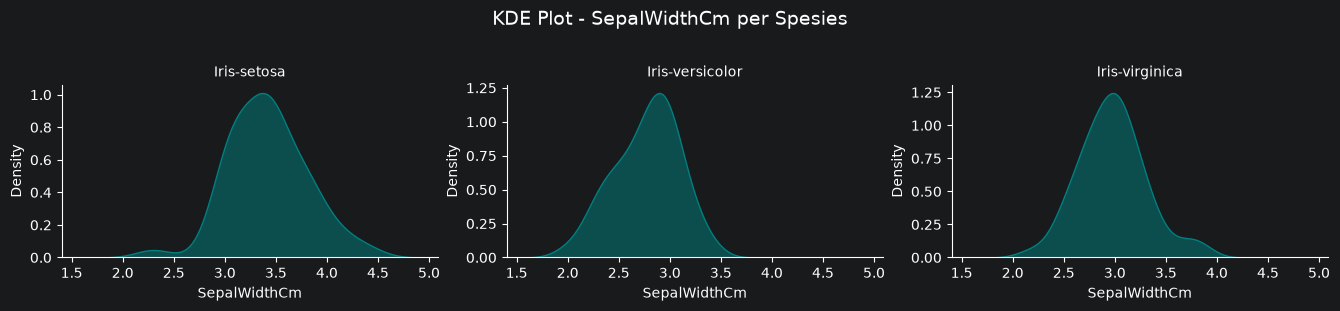

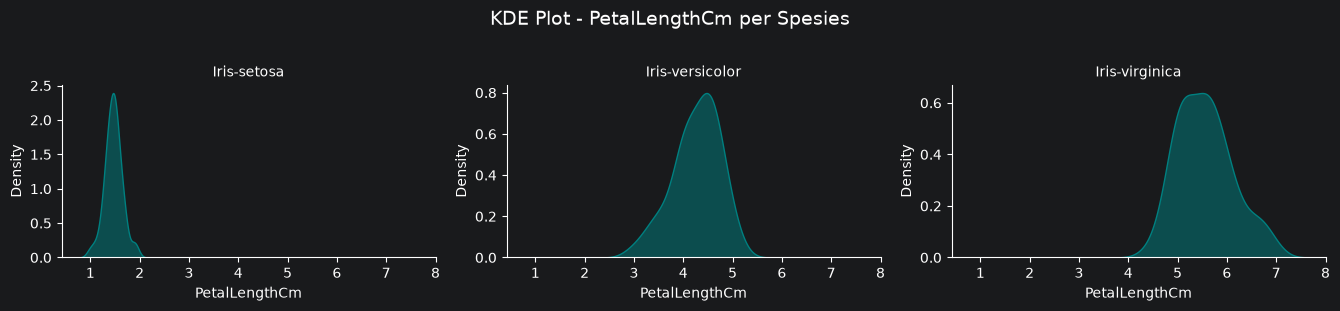

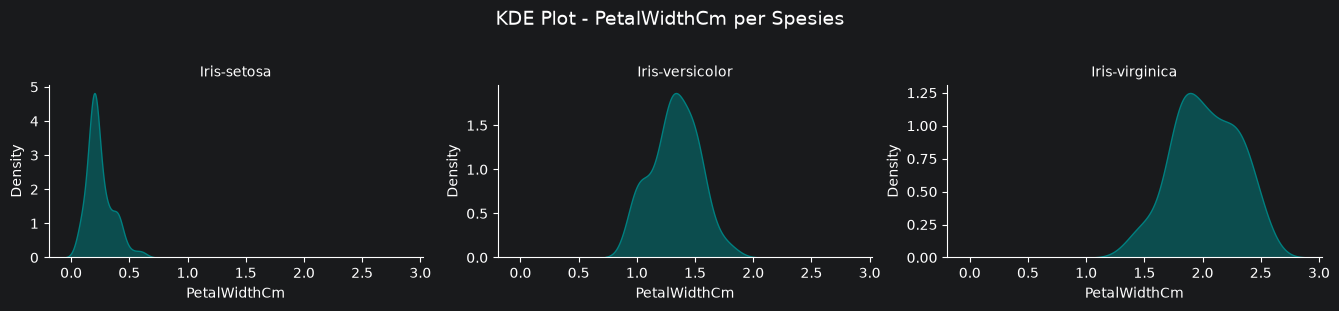

In [87]:
for col in num_cols:
    g = sns.FacetGrid(
        data,
        col='label',
        col_wrap=3,
        sharex=True,
        sharey=False,
        height=3,
        aspect=1.5
    )
    g.map(sns.kdeplot, col, fill=True, color='teal', alpha=0.5)
    g.set_titles("{col_name}")
    g.fig.suptitle(f'KDE Plot - {col} per Spesies', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

### 3.8. Distribusi Label (Count Plot)

Visualisasi jumlah sampel per spesies untuk memastikan dataset seimbang (*balanced*).

/tmp/ipykernel_51944/2815278349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=data, palette='Set2')


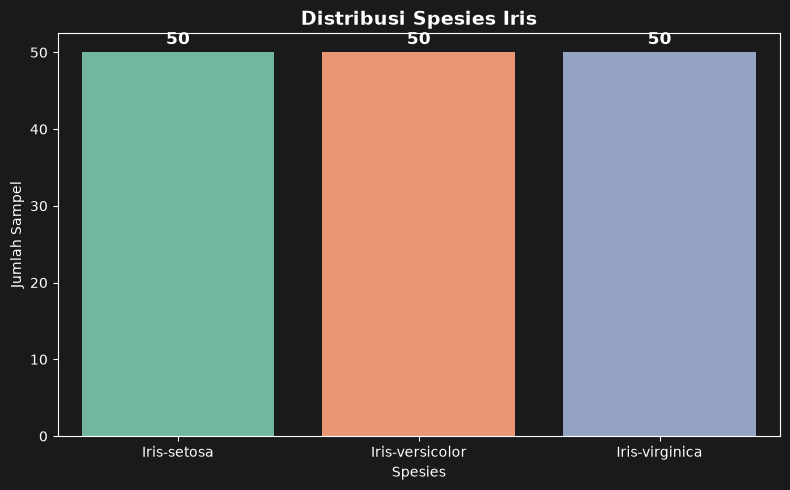

In [88]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=data, palette='Set2')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=12, fontweight='bold')

plt.title('Distribusi Spesies Iris', fontsize=14, fontweight='bold')
plt.xlabel('Spesies')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

### 4.1. Pisahkan Fitur dan Target

Memisahkan kolom fitur (X) yang akan digunakan untuk memprediksi, dan kolom target/label (y) yang ingin diprediksi.

In [89]:
X = data.drop(columns='label').copy()
y = data['label']

### 4.2. Penanganan Outlier dengan Metode Kuartil (IQR - Interquartile Range)

Mengatasi nilai ekstrem (*outliers*) menggunakan metode rentang antar-kuartil (**IQR**). Nilai di luar batas bawah dan batas atas akan dibatasi (*capping / winsorizing*) agar tidak merusak distribusi data dan pembobotan model.

**Rumus IQR:**
- $Q_1$ = Kuartil 1 (Persentil 25)
- $Q_3$ = Kuartil 3 (Persentil 75)
- $IQR = Q_3 - Q_1$
- $\text{Lower Bound} = Q_1 - 1.5 \times IQR$
- $\text{Upper Bound} = Q_3 + 1.5 \times IQR$

> 💡 **Capping (Winsorizing):** Mengganti nilai $< \text{Lower Bound}$ menjadi $\text{Lower Bound}$, dan nilai $> \text{Upper Bound}$ menjadi $\text{Upper Bound}$ tanpa menghapus baris data.

In [90]:
# Penanganan Outlier dengan metode IQR Capping
num_cols = X.columns

print("📊 Batas IQR untuk setiap fitur:")
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung jumlah outlier sebelum capping
    n_outliers = ((X[col] < lower_bound) | (X[col] > upper_bound)).sum()
    print(f"   - {col:12s}: Q1={Q1:6.2f}, Q3={Q3:6.2f}, IQR={IQR:6.2f} | Outliers={n_outliers:2d} | Range: [{lower_bound:6.2f}, {upper_bound:6.2f}]")
    
    # Capping nilai di luar batas IQR
    X[col] = np.clip(X[col], lower_bound, upper_bound)

print("\n✅ Penanganan outlier dengan metode IQR Capping selesai!")

📊 Batas IQR untuk setiap fitur:
   - SepalLengthCm: Q1=  5.10, Q3=  6.40, IQR=  1.30 | Outliers= 0 | Range: [  3.15,   8.35]
   - SepalWidthCm: Q1=  2.80, Q3=  3.30, IQR=  0.50 | Outliers= 4 | Range: [  2.05,   4.05]
   - PetalLengthCm: Q1=  1.60, Q3=  5.10, IQR=  3.50 | Outliers= 0 | Range: [ -3.65,  10.35]
   - PetalWidthCm: Q1=  0.30, Q3=  1.80, IQR=  1.50 | Outliers= 0 | Range: [ -1.95,   4.05]

✅ Penanganan outlier dengan metode IQR Capping selesai!


#### Visualisasi Box Plot Setelah Penanganan Outlier

Menampilkan ulang Box Plot dari seluruh fitur numerik setelah dilakukan penanganan outlier dengan metode IQR Capping.

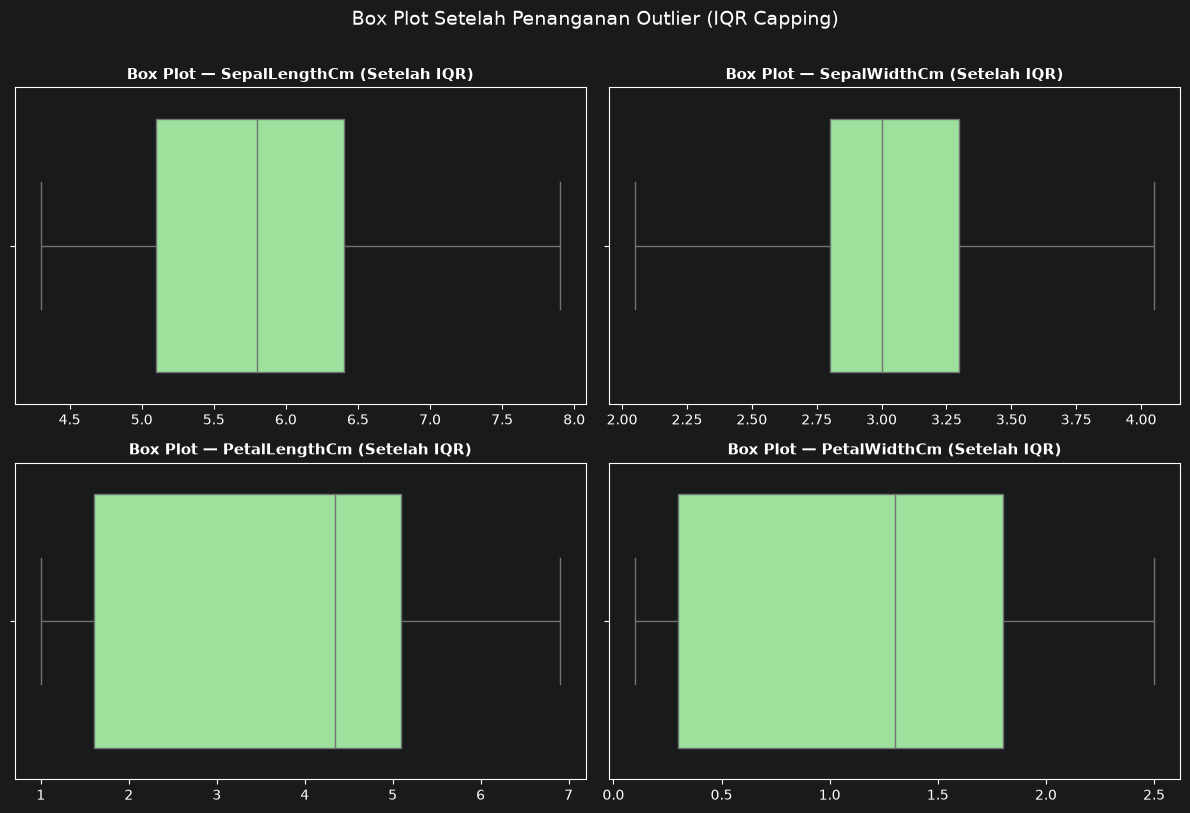

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(x=X[col], color='lightgreen', ax=axes[i])
    axes[i].set_title(f'Box Plot — {col} (Setelah IQR)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Box Plot Setelah Penanganan Outlier (IQR Capping)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.3. Normalisasi Fitur (MinMaxScaler)

Mengubah skala fitur agar berada dalam rentang [0, 1] menggunakan MinMaxScaler.

In [92]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

print("Contoh data setelah MinMaxScaler (5 baris pertama):")
print(pd.DataFrame(X, columns=['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']).head())
print(f"\nRange nilai: [{X.min():.2f}, {X.max():.2f}]")

Contoh data setelah MinMaxScaler (5 baris pertama):
   SepalLength  SepalWidth  PetalLength  PetalWidth
0     0.222222       0.725     0.067797    0.041667
1     0.166667       0.475     0.067797    0.041667
2     0.111111       0.575     0.050847    0.041667
3     0.083333       0.525     0.084746    0.041667
4     0.194444       0.775     0.067797    0.041667

Range nilai: [0.00, 1.00]


### 4.4. Encoding Label (LabelEncoder)

Mengubah label kelas berupa teks (kategorikal) menjadi angka (numerik).

In [93]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


### 4.5. Bagi Data Latih dan Uji (70:30)

Membagi dataset menjadi 70% data latih dan 30% data uji.

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3, stratify=y)

print(f"Train set shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Test set shape:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")
print(f"\nRasio: {len(y_train)}/{len(y_test)} = {len(y_train)/len(y_test):.1f}:1")

Train set shape: X_train = (105, 4), y_train = (105,)
Test set shape:  X_test  = (45, 4), y_test  = (45,)

Rasio: 105/45 = 2.3:1


---
## 5. Model Training

Melatih 5 algoritma klasifikasi pada data latih. Di notebook ini kita menggunakan **Logistic Regression** sebagai pengganti Naive Bayes.

**Konsep:**
- `.fit(X_train, y_train)` → proses pembelajaran model dari data latih
- **KNN** → mencari k tetangga terdekat, voting mayoritas
- **Decision Tree** → pohon keputusan, split fitur berdasarkan information gain
- **Random Forest** → ensemble dari banyak Decision Trees
- **SVM** → mencari hyperplane pemisah dengan margin maksimal
- **Logistic Regression** → model linear yang menggunakan fungsi sigmoid untuk klasifikasi

In [95]:
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
lr = LogisticRegression(max_iter=200).fit(X_train, y_train)

print("Training selesai untuk 5 model:")
print("1. K-Nearest Neighbors (KNN)")
print("2. Decision Tree")
print("3. Random Forest")
print("4. Support Vector Machine (SVM)")
print("5. Logistic Regression")

Training selesai untuk 5 model:
1. K-Nearest Neighbors (KNN)
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. Logistic Regression


---
## 6. Model Evaluation

Mengevaluasi performa setiap model menggunakan metrik klasifikasi dan confusion matrix.

**Konsep:**
- Fungsi ini melakukan prediksi dan menghitung semua metrik evaluasi sekaligus
- `classification_report` → laporan lengkap per kelas (precision, recall, f1-score)
- Mengembalikan dictionary metrik untuk perbandingan nanti

==== KNN ====
Accuracy  : 0.9111
Precision : 0.9298
Recall    : 0.9111
F1-Score  : 0.9095

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      1.00      0.88        15
 Iris-virginica       1.00      0.73      0.85        15

       accuracy                           0.91        45
      macro avg       0.93      0.91      0.91        45
   weighted avg       0.93      0.91      0.91        45



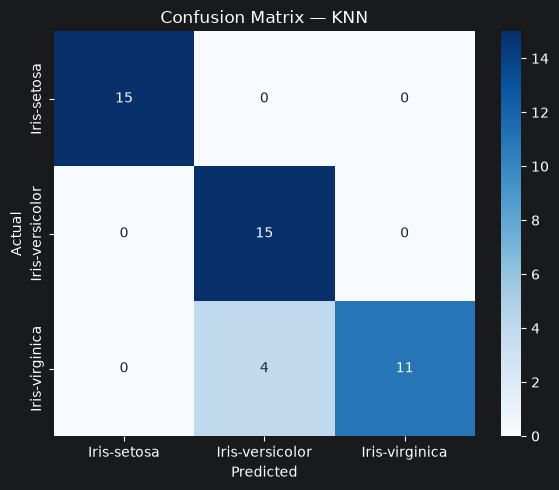



==== Decision Tree ====
Accuracy  : 0.8889
Precision : 0.8899
Recall    : 0.8889
F1-Score  : 0.8888

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.86      0.80      0.83        15
 Iris-virginica       0.81      0.87      0.84        15

       accuracy                           0.89        45
      macro avg       0.89      0.89      0.89        45
   weighted avg       0.89      0.89      0.89        45



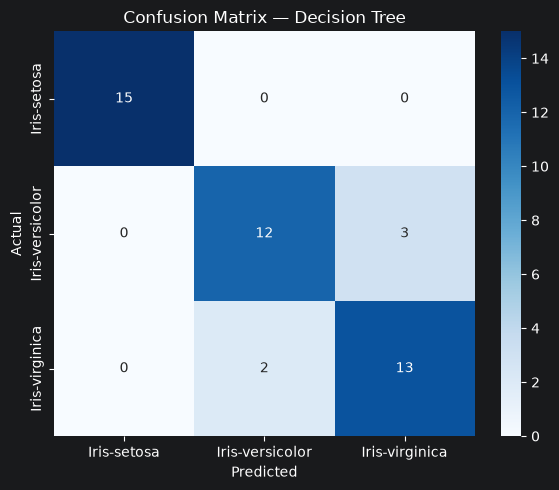



==== Random Forest ====
Accuracy  : 0.8889
Precision : 0.8981
Recall    : 0.8889
F1-Score  : 0.8878

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.78      0.93      0.85        15
 Iris-virginica       0.92      0.73      0.81        15

       accuracy                           0.89        45
      macro avg       0.90      0.89      0.89        45
   weighted avg       0.90      0.89      0.89        45



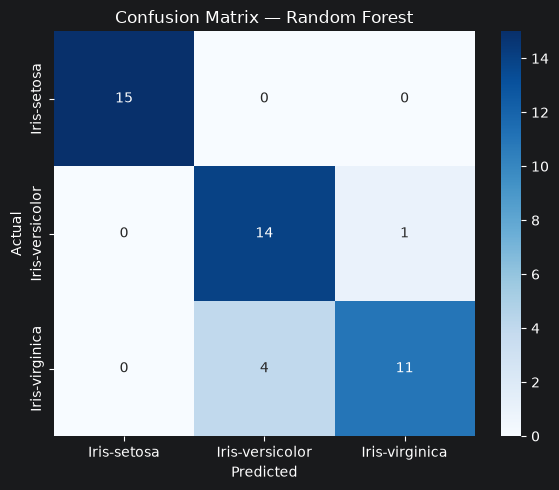



==== SVM ====
Accuracy  : 0.9333
Precision : 0.9345
Recall    : 0.9333
F1-Score  : 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



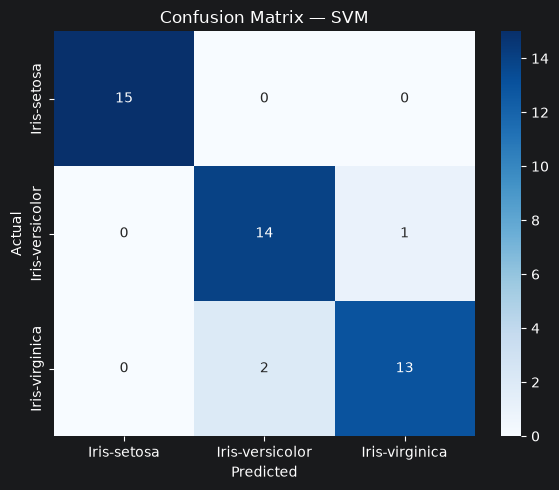



==== Logistic Regression ====
Accuracy  : 0.8444
Precision : 0.8452
Recall    : 0.8444
F1-Score  : 0.8443

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      0.73      0.76        15
 Iris-virginica       0.75      0.80      0.77        15

       accuracy                           0.84        45
      macro avg       0.85      0.84      0.84        45
   weighted avg       0.85      0.84      0.84        45



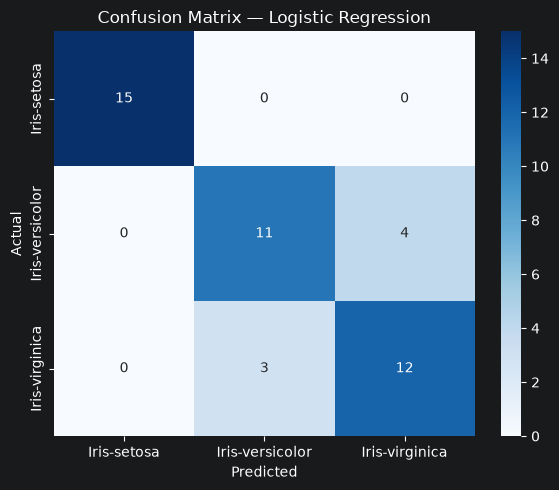

In [96]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def evaluate_model(name, model, X_test, y_test, label_names):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"==== {name} ====")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))

    #Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
    }

# Jalankan semua model sekaligus
label_names = label_encoder.classes_
results = []

results.append(evaluate_model("KNN", knn, X_test, y_test, label_names))
results.append(evaluate_model("Decision Tree", dt, X_test, y_test, label_names))
results.append(evaluate_model("Random Forest", rf, X_test, y_test, label_names))
results.append(evaluate_model("SVM", svm, X_test, y_test, label_names))
results.append(evaluate_model("Logistic Regression", lr, X_test, y_test, label_names))

---
## 7. Model Comparison

Membandingkan performa berbagai model yang telah dilatih secara berdampingan untuk menentukan model mana yang memberikan hasil terbaik secara keseluruhan.

In [97]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    #Untuk multiclass, TP/FP/FN/TN dihitung per kelas lalu dijumlah
    tp = cm.diagonal().sum()                        #semua prediksi benar
    fp = cm.sum(axis=0) - cm.diagonal()            #diprediksi X tapi bukan X
    fn = cm.sum(axis=1) - cm.diagonal()            #seharusnya X tapi diprediksi lain
    tn = cm.sum() - (tp + fp.sum() + fn.sum())     #semua yang bukan kelas itu & benar

    result = {
        "Confusion Matrix": cm,
        "True Positive":  tp,
        "False Positive": fp.sum(),
        "False Negative": fn.sum(),
        "True Negative":  tn,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall":    recall_score(y_test, y_pred, average='weighted'),
        "F1-Score":  f1_score(y_test, y_pred, average='weighted')
    }
    return result

# evaluasi setiap model
result = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)':        evaluate_model(dt,  X_test, y_test),
    'Random Forest (RF)':        evaluate_model(rf,  X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Logistic Regression (LR)':  evaluate_model(lr,  X_test, y_test)
}

# summary table
rows = []
for model_name, metrics in result.items():
    rows.append({
        "Model":     model_name,
        "Accuracy":  metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall":    metrics["Recall"],
        "F1-Score":  metrics["F1-Score"]
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

                       Model  Accuracy  Precision   Recall  F1-Score
   K-Nearest Neighbors (KNN)  0.911111   0.929825 0.911111  0.909502
          Decision Tree (DT)  0.888889   0.889881 0.888889  0.888765
          Random Forest (RF)  0.888889   0.898148 0.888889  0.887767
Support Vector Machine (SVM)  0.933333   0.934524 0.933333  0.933259
    Logistic Regression (LR)  0.844444   0.845238 0.844444  0.844271


---
## 8. Visualisasi Performa Model

### 8.1. Visualizing Model Performance

Membuat grafik perbandingan metrik evaluasi dari semua model agar lebih mudah dipahami secara visual.

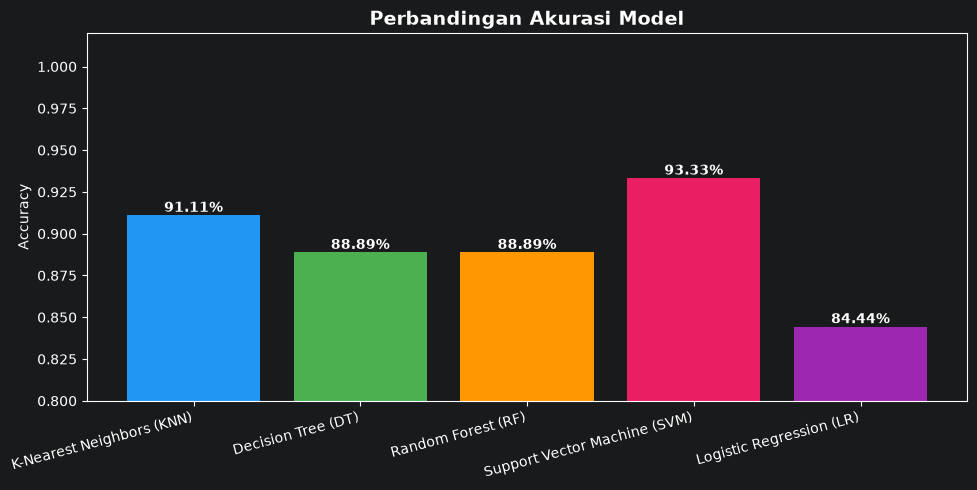

In [98]:
plt.figure(figsize=(10, 5))
bars = plt.bar(summary_df['Model'], summary_df['Accuracy'],
               color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'])
plt.title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=15, ha='right')

# tampilin angka di atas tiap bar
for bar, val in zip(bars, summary_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2. Heatmap Semua Metrik

Menampilkan *heatmap* metrik performa untuk memberikan tampilan yang lebih terstruktur terkait perbandingan antara tiap model terhadap tiap metrik (*Accuracy, Precision, Recall, F1*).

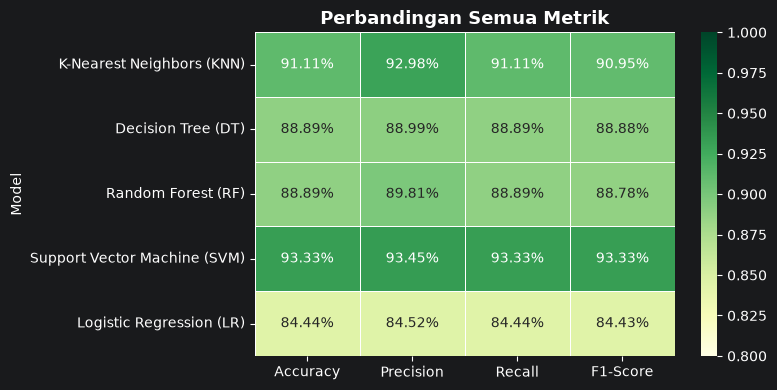

In [99]:
metrics_df = summary_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]

plt.figure(figsize=(8, 4))
sns.heatmap(metrics_df, annot=True, fmt='.2%', cmap='YlGn',
            vmin=0.8, vmax=1.0, linewidths=0.5)
plt.title('Perbandingan Semua Metrik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Best Model & Error Analysis

Menentukan model terbaik (*Best Model*), kemudian melakukan analisis lanjutan, seperti melihat *Confusion Matrix* untuk mencari tahu di kelas mana model sering melakukan kesalahan klasifikasi (*Error Analysis*).

Model terbaik: Support Vector Machine (SVM)


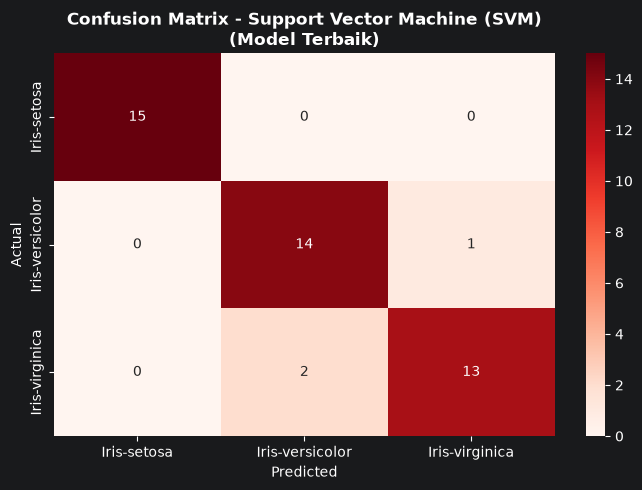

In [100]:
# ambil model terbaik otomatis
best_model_name = summary_df.loc[summary_df['Accuracy'].idxmax(), 'Model']
print(f"Model terbaik: {best_model_name}")

# mapping nama model ke objek
model_map = {
    'K-Nearest Neighbors (KNN)': knn,
    'Decision Tree (DT)': dt,
    'Random Forest (RF)': rf,
    'Support Vector Machine (SVM)': svm,
    'Logistic Regression (LR)': lr
}
best_model = model_map[best_model_name]
y_pred_best = best_model.predict(X_test)

# Confusion matrix untuk kelas yang paling sering salah
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}\n(Model Terbaik)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
## 10. Menyimpan Model (Save Model)

Setelah menemukan model terbaik, langkah selanjutnya adalah menyimpan model beserta `scaler` dan `label_encoder` ke dalam file agar bisa digunakan kembali tanpa harus melatih ulang.

**Konsep:**
- `joblib` → library untuk menyimpan (serialize) dan memuat (deserialize) objek Python secara efisien
- Kita perlu menyimpan **3 komponen**:
  1. **Model** → objek model yang sudah dilatih
  2. **Scaler** → StandardScaler yang sudah di-fit, agar data baru dinormalisasi dengan cara yang sama
  3. **LabelEncoder** → untuk mengonversi hasil prediksi angka kembali ke label asli
- File disimpan ke folder `model/` agar terorganisir

In [101]:
import joblib
import os

# Buat folder model jika belum ada
os.makedirs('../model', exist_ok=True)

# Simpan model terbaik
joblib.dump(best_model, '../model/best_iris_model.joblib')
print(f"Model '{best_model_name}' berhasil disimpan ke: model/best_iris_model.joblib")

# Simpan scaler
joblib.dump(scaler, '../model/iris_scaler.joblib')
print(f"Scaler berhasil disimpan ke: model/iris_scaler.joblib")

# Simpan label encoder
joblib.dump(label_encoder, '../model/iris_label_encoder.joblib')
print(f"Label Encoder berhasil disimpan ke: model/iris_label_encoder.joblib")

Model 'Support Vector Machine (SVM)' berhasil disimpan ke: model/best_iris_model.joblib
Scaler berhasil disimpan ke: model/iris_scaler.joblib
Label Encoder berhasil disimpan ke: model/iris_label_encoder.joblib


---
## 11. Memuat Model dan Pengujian (Load Model & Testing)

Sekarang kita akan memuat kembali model yang sudah disimpan dan mengujinya dengan data baru untuk membuktikan bahwa model dapat digunakan **tanpa harus melatih ulang**.

**Konsep:**
- `joblib.load()` → memuat objek Python yang telah disimpan sebelumnya
- Alur penggunaan model yang sudah disimpan:
  1. Load model, scaler, dan label encoder dari file
  2. Transformasi data baru menggunakan scaler yang sama (`scaler.transform()`)
  3. Prediksi menggunakan model (`model.predict()`)
  4. Konversi hasil prediksi ke label asli (`label_encoder.inverse_transform()`)

> ⚠️ **Penting:** Gunakan `scaler.transform()` (bukan `fit_transform()`) pada data baru, agar data dinormalisasi dengan parameter yang sama seperti saat training.

In [102]:
# Load model, scaler, dan label encoder
loaded_model = joblib.load('../model/best_iris_model.joblib')
loaded_scaler = joblib.load('../model/iris_scaler.joblib')
loaded_encoder = joblib.load('../model/iris_label_encoder.joblib')

print("Model berhasil dimuat dari: model/best_iris_model.joblib")
print(f"Tipe model: {type(loaded_model).__name__}")
print(f"Label kelas: {list(loaded_encoder.classes_)}")

Model berhasil dimuat dari: model/best_iris_model.joblib
Tipe model: SVC
Label kelas: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


### 11.1. Pengujian dengan Data Test Set

Pertama, kita uji model yang dimuat dengan data test set yang sama untuk memastikan hasilnya **identik** dengan model asli.

In [103]:
# Prediksi menggunakan model yang dimuat
y_pred_loaded = loaded_model.predict(X_test)

# Bandingkan dengan prediksi model asli
from sklearn.metrics import accuracy_score

acc_loaded = accuracy_score(y_test, y_pred_loaded)
acc_original = accuracy_score(y_test, y_pred_best)

print(f"Akurasi model asli     : {acc_original:.4f}")
print(f"Akurasi model dimuat   : {acc_loaded:.4f}")
print()

if acc_loaded == acc_original:
    print("Hasil IDENTIK! Model berhasil disimpan dan dimuat dengan benar.")
else:
    print("Hasil BERBEDA! Ada masalah dalam proses save/load.")

Akurasi model asli     : 0.9333
Akurasi model dimuat   : 0.9333

Hasil IDENTIK! Model berhasil disimpan dan dimuat dengan benar.


### 11.2. Pengujian dengan Data Baru

Sekarang kita coba prediksi menggunakan **data baru yang belum pernah dilihat model**. Ini mensimulasikan penggunaan model di dunia nyata (production).

**Alur:**
1. Buat data baru dalam bentuk DataFrame
2. Transformasi dengan `loaded_scaler.transform()` (⚠️ bukan `fit_transform`!)
3. Prediksi dengan `loaded_model.predict()`
4. Konversi ke label asli dengan `loaded_encoder.inverse_transform()`

In [104]:
# Contoh data baru: [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
data_baru = {
    'SepalLengthCm': [5.1],
    'SepalWidthCm': [3.5],
    'PetalLengthCm': [1.4],
    'PetalWidthCm': [0.2]
}

df_baru = pd.DataFrame(data_baru)
print("Data input:")
print(df_baru)
print()

# Transformasi data baru menggunakan scaler yang sudah di-load
# Gunakan transform() BUKAN fit_transform()!
data_scaled = loaded_scaler.transform(df_baru)
print("Data setelah di-scale:")
print(data_scaled)
print()

# Prediksi
prediksi = loaded_model.predict(data_scaled)
print(f"Hasil prediksi (numerik): {prediksi}")

# Prediksi spesies bunga Iris
prediksi_label = loaded_encoder.inverse_transform(prediksi)
print(f"Spesies Iris yang diprediksi: {prediksi_label[0]}")

Data input:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2

Data setelah di-scale:
[[0.22222222 0.725      0.06779661 0.04166667]]

Hasil prediksi (numerik): [0]
Spesies Iris yang diprediksi: Iris-setosa


---
### 📝 Ringkasan Save & Load Model

| Langkah | Fungsi | File |
|---------|--------|------|
| Simpan Model | `joblib.dump(model, path)` | `model/best_iris_model.joblib` |
| Simpan Scaler | `joblib.dump(scaler, path)` | `model/iris_scaler.joblib` |
| Simpan Encoder | `joblib.dump(encoder, path)` | `model/iris_label_encoder.joblib` |
| Muat Model | `joblib.load(path)` | — |
| Transformasi | `scaler.transform(X)` | ⚠️ Bukan `fit_transform`! |
| Prediksi | `model.predict(X_scaled)` | — |
| Decode Label | `encoder.inverse_transform(y)` | — |

> 💡 **Tips:** Selalu simpan **scaler** dan **label encoder** bersama model. Tanpa keduanya, model tidak bisa digunakan dengan benar pada data baru!